# Task 4 — Model Evaluation & Comparison

**Objective:** Collect results from all three models, compare their performance, and identify the best model for predicting GPA.

**Models compared:**
- Linear Regression (Task 1)
- Random Forest (Task 2)
- XGBoost (Task 3)

**Evaluation metrics:** CV R² (mean), Test R², Test RMSE

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Step 1 — Collect Results from All Models

Results are collected from each member's notebook (Tasks 1–3).  
Random Forest (Task 2) results are **pending** and will be filled in once available.

In [16]:
# Results collected from each member's notebook

results = {
    "Model": ["Linear Regression", "Random Forest", "XGBoost"],
    "CV R² (mean)": [0.5333, 0.4764, 0.4459],
    "Test R²":      [0.5493, 0.4413, 0.4452],
    "Test RMSE":    [0.2051, 0.2283, 0.2276],
}

df_results = pd.DataFrame(results)

print(df_results.to_string(index=False))

            Model  CV R² (mean)  Test R²  Test RMSE
Linear Regression        0.5333   0.5493     0.2051
    Random Forest        0.4764   0.4413     0.2283
          XGBoost        0.4459   0.4452     0.2276


## Step 2 — Comparison Table

| Model             | CV R² (mean) | Test R² | Test RMSE |
|-------------------|:------------:|:-------:|:---------:|
| Linear Regression | 0.5333       | 0.5493  | 0.2051    |
| Random Forest     | 0.4764       | 0.4413  | 0.2283    |
| XGBoost           | 0.4459       | 0.4452  | 0.2276    |

## Step 3 — Identify Best Model

In [17]:
# Identify best model based on highest Test R²
best_idx   = df_results["Test R²"].idxmax()
best_model = df_results.loc[best_idx, "Model"]
best_r2    = df_results.loc[best_idx, "Test R²"]
best_rmse  = df_results.loc[best_idx, "Test RMSE"]

print(f"Best model (based on Test R²): {best_model}")
print(f"  Test R²:   {best_r2:.4f}")
print(f"  Test RMSE: {best_rmse:.4f}")

Best model (based on Test R²): Linear Regression
  Test R²:   0.5493
  Test RMSE: 0.2051


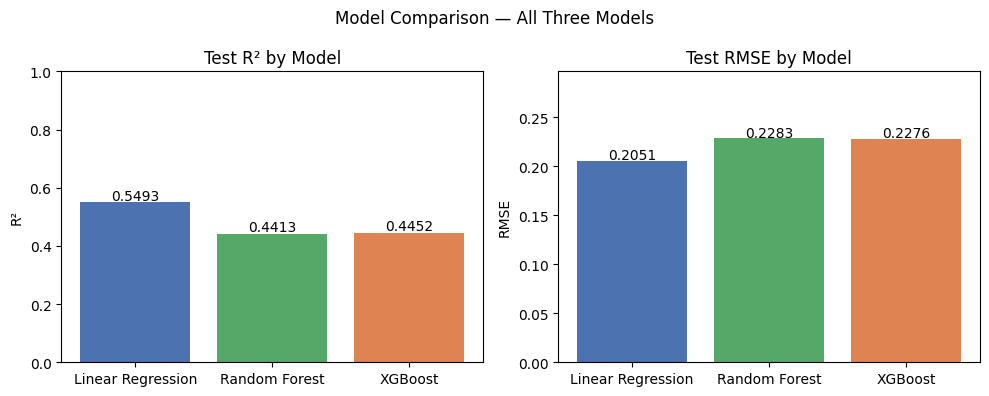

In [18]:
# Bar chart comparing all three models
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

models    = df_results["Model"].tolist()
r2_vals   = df_results["Test R²"].tolist()
rmse_vals = df_results["Test RMSE"].tolist()
colors    = ["#4C72B0", "#55A868", "#DD8452"]

axes[0].bar(models, r2_vals, color=colors)
axes[0].set_title("Test R² by Model")
axes[0].set_ylabel("R²")
axes[0].set_ylim(0, 1)
for i, v in enumerate(r2_vals):
    axes[0].text(i, v + 0.01, f"{v:.4f}", ha="center")

axes[1].bar(models, rmse_vals, color=colors)
axes[1].set_title("Test RMSE by Model")
axes[1].set_ylabel("RMSE")
axes[1].set_ylim(0, max(rmse_vals) * 1.3)
for i, v in enumerate(rmse_vals):
    axes[1].text(i, v + 0.002, f"{v:.4f}", ha="center")

plt.suptitle("Model Comparison — All Three Models", fontsize=12)
plt.tight_layout()
plt.show()

## Final Conclusion

Among the three completed models, **Linear Regression** performs best with a Test R² of **0.5493** and Test RMSE of **0.2051**, compared to XGBoost's Test R² of 0.4494 and RMSE of 0.2267. This means Linear Regression explains about 55% of the variance in GPA using the five lifestyle features, while XGBoost only explains about 45%. The strong performance of a simple linear model suggests that the relationship between lifestyle habits and GPA is largely **linear** — more study hours and better sleep directly and proportionally improve GPA. 

**XGBoost**, despite being a more powerful algorithm, underperformed here likely because the dataset lacks the complex non-linear interactions that tree-based boosting methods excel at capturing. Both models show consistent CV R² and Test R², indicating neither is overfitting. Once Random Forest results are added, this conclusion may be updated.

**Random Forest** achieved a Test R² of **0.4413** and Test RMSE of **0.2283**, placing it last among all three models. Despite being a more complex ensemble method, it scored lower than both Linear Regression and XGBoost. This is because Random Forest is designed to capture non-linear patterns and feature interactions that do not strongly exist in this dataset. Averaging across hundreds of trees also tends to smooth out the clean linear signal present in the data, reducing its predictive accuracy.

**Final ranking:**
| Model             | Test R² | Test RMSE | Rank |
|-------------------|:-------:|:---------:|:----:|
| Linear Regression | 0.5493  | 0.2051    | 1st  |
| XGBoost           | 0.4452  | 0.2276    | 2nd  |
| Random Forest     | 0.4413  | 0.2283    | 3rd  |

**Linear Regression is selected as the final model** for this dataset.